In [2]:
pip install easyocr --user

  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
basemap 1.4.1 requires numpy<1.27,>=1.21; python_version >= "3.8", but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [4]:
pip install "numpy<2" --force-reinstall --user

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [1]:
#Packages and Libraries
from pdf2image import convert_from_path     #library that converts PDFs for redability
import pandas as pd                         #library that reads data files and creates/modifies datasets
import cv2                                  #image modification library
#import easyocr                              #Engine that reads images and creates strings/columns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import easyocr

Converting PDF page to image...
Card Image Dimensions: 1700x2200 pixels


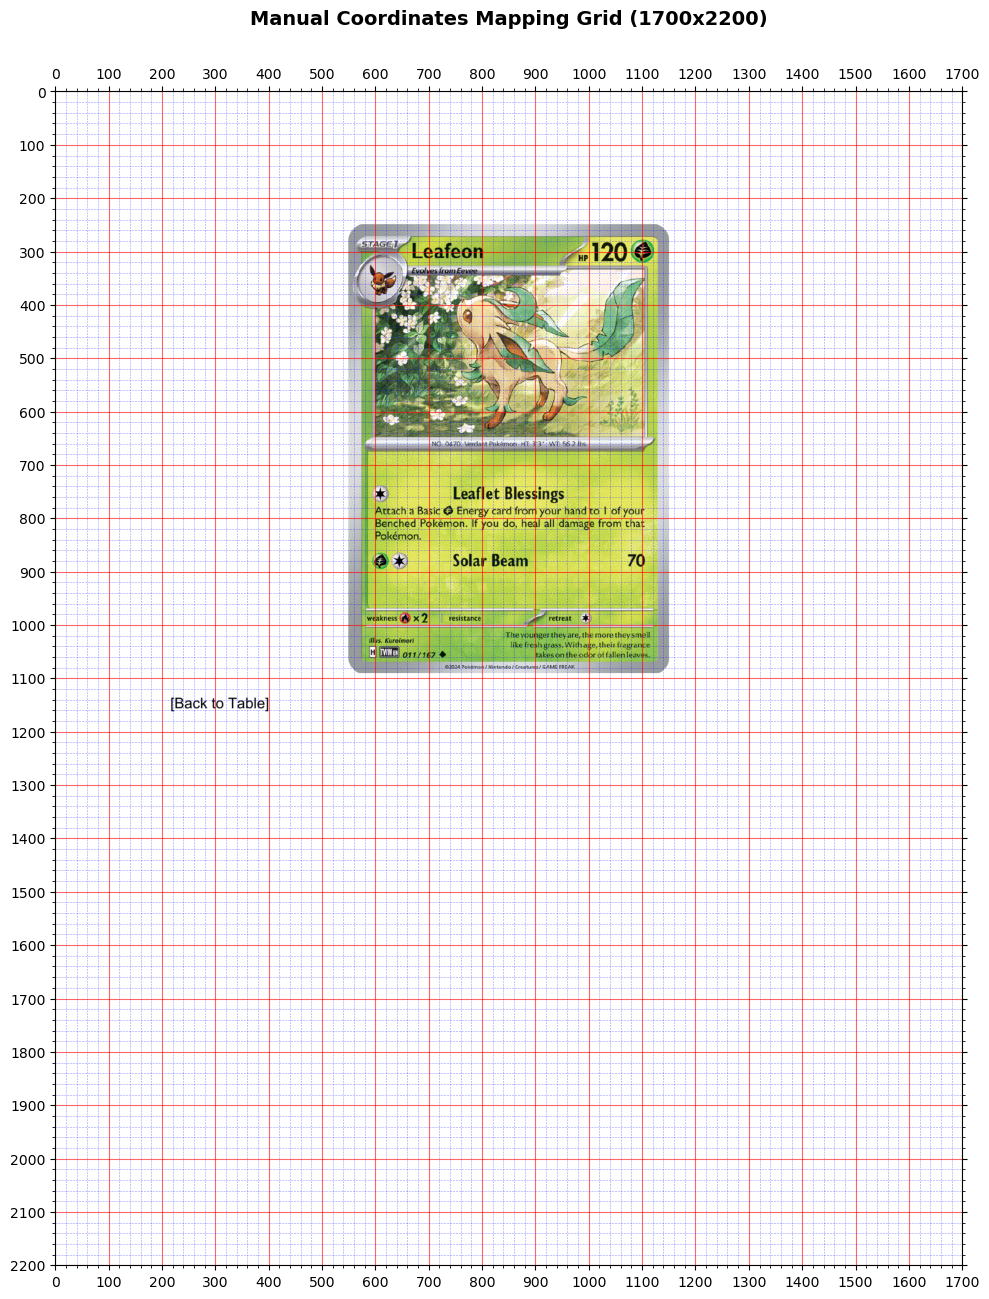

In [3]:
# 1. Extract a single card page
# Adjust page number and dpi as needed (higher DPI = higher resolution grid)
print("Converting PDF page to image...")
images = convert_from_path('Card_ID List_EN.pdf', first_page=65, last_page=65, dpi=200)
card_array = np.array(images[0])

# Get pixel dimensions
height, width, _ = card_array.shape
print(f"Card Image Dimensions: {width}x{height} pixels")

# 2. Setup the Plot
fig, ax = plt.subplots(figsize=(10, 14), dpi=100)
ax.imshow(card_array)

# 3. Create a Detailed Pixel Grid Overlay
# Major ticks every 100 pixels, minor ticks every 20 pixels
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(20))
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))

# Style the grid lines
# Major grid: Solid, darker line with labels
ax.grid(True, which='major', color='red', linestyle='-', linewidth=0.8, alpha=0.6)
# Minor grid: Dashed, lighter line for precision mapping
ax.grid(True, which='minor', color='blue', linestyle='--', linewidth=0.4, alpha=0.4)

# Ensure ticks and labels are visible on all sides for easy referencing
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, labeltop=True, labelleft=True)
ax.set_xlim(0, width)
# Invert Y-axis because matrix rows start at 0 at the top
ax.set_ylim(height, 0) 

plt.title(f"Manual Coordinates Mapping Grid ({width}x{height})", y=1.05, fontsize=14, weight='bold')
plt.tight_layout()

# 4. Display or Save the Image
# If running in a Jupyter Notebook, it will show automatically. 
# Otherwise, save it as a high-res image to open and inspect zoom levels.
plt.savefig("card_blueprint_grid.png", bbox_inches='tight', dpi=300)
plt.show()

New Cropped Dimensions: 620x860 pixels


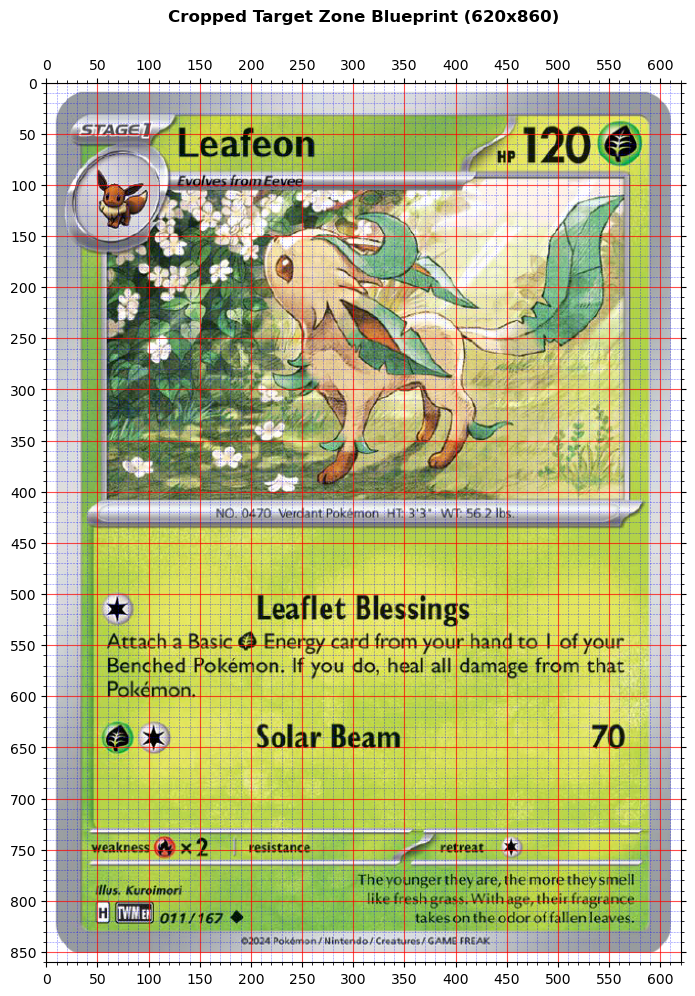

Success! Grid overlay saved to 'cropped_card_blueprint.png'.


In [4]:
# Define your boundaries (adjusting for the Left/Right swap)
ymin, ymax = 240, 1100  # Top to Bottom
xmin, xmax = 540, 1160  # Left to Right

# Crop the image using native NumPy slicing: [Rows, Columns]
cropped_card = card_array[ymin:ymax, xmin:xmax]
c_height, c_width, _ = cropped_card.shape
print(f"New Cropped Dimensions: {c_width}x{c_height} pixels")

# 3. Setup the New Matplotlib Canvas for the Cropped Region
fig, ax = plt.subplots(figsize=(8, 10), dpi=100)
ax.imshow(cropped_card)

# 4. Apply a Super-Fine Grid Overlay
# Major grid lines every 50 pixels, Minor grid lines every 10 pixels
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))

# Style the grid lines for maximum visibility over card textures
ax.grid(True, which='major', color='red', linestyle='-', linewidth=0.8, alpha=0.7)
ax.grid(True, which='minor', color='blue', linestyle='--', linewidth=0.4, alpha=0.5)

# Place labels on all borders for fast cross-referencing
ax.tick_params(which='both', top=True, bottom=True, left=True, right=True, labeltop=True, labelleft=True)

# Clamp the plot limits tightly to the cropped array boundaries
ax.set_xlim(0, c_width)
ax.set_ylim(c_height, 0) # Keeps top-left as (0,0) relative to the new crop

plt.title(f"Cropped Target Zone Blueprint ({c_width}x{c_height})", y=1.06, fontsize=12, weight='bold')
plt.tight_layout()

# 5. Save the cropped blueprint image
output_filename = "cropped_card_blueprint.png"
plt.savefig(output_filename, bbox_inches='tight', dpi=300)
plt.show()

print(f"Success! Grid overlay saved to '{output_filename}'.")

In [7]:
#ymin, ymax, xmin, xmax pixel coordinates on minigrid ENERGY CARD
Textbox1a = [30, 60, 40, 250]    #Energy Type
Textbox2b = [30, 60, 350, 590]   #Card Type
Textbox3c = [70, 120, 40, 500]   #Card Name
Textbox4d = [797, 820, 65, 105]  #Expansion Code
Textbox5e = [809, 820, 110, 140] #Collector Number

# a dictionary mapping the variable name to its coordinates
all_boxes_E = {
    'Energy Type': Textbox1a, 'Card Type': Textbox2b, 'Card Name': Textbox3c, 
    'Expansion Code': Textbox4d, 'Collector No.': Textbox5e
}

In [9]:
#ymin, ymax,xmin, xmax bottom pixel coordinates on minigrid TRAINER CARD
TextboxA = [30, 60, 40, 250]    #Trainer Type
TextboxB = [30, 60, 390, 590]   #Card Type
TextboxC = [70, 120, 40, 500]   #Card Name
TextboxD = [450, 740, 50, 570]  #Textbox
TextboxE = [750, 810, 230, 570] #Trainer Rule
TextboxF = [800, 820, 70, 105]  #Expansion Code
TextboxG = [810, 820, 110, 180] #Collector Number
TextboxH = [780, 792, 48, 160]  #Illustrator

# a dictionary mapping the variable name to its coordinates
all_boxes_T = {
    'Trainer Type': TextboxA, 'Card Type': TextboxB, 'Card Name': TextboxC, 
    'Textbox': TextboxD, 'Trainer Rule': TextboxE, 'Expansion Code': TextboxF, 
    'Collector No.': TextboxG, 'Illustrator': TextboxH
}

In [11]:
#left, right, top, bottom pixel coordinates on minigrid POKEMON CARD
Textbox1 = [30, 60, 30, 103]     #Stage Textbox
Textbox2 = [40, 90, 120, 250]    #Card Name Textbox
Textbox3 = [40, 90, 460, 540]    #HP Textbox
Textbox4 = [90, 105, 120, 400]   #Evolves From Textbox     - correct this
Textbox5 = [440, 730, 50, 580]   #Actions Textbox
Textbox6 = [740, 760, 40, 180]   #wekaness Textbox         
Textbox7 = [740, 760, 190, 340]  #resistance Textbox       
Textbox8 = [740, 760, 380, 580]  #retreat Textbox          
Textbox9 = [800, 820, 70, 105]   #expansion code Textbox   
Textbox10 = [800, 830, 110, 140] #collector number Textbox
Textbox11 = [780, 797,48, 190]  #Illustrator

# a dictionary mapping the variable name to its coordinates
all_boxes_P = {
    'Stage': Textbox1, 'Card Name': Textbox2, 'HP': Textbox3, 
    'Evolves': Textbox4, 'Actions': Textbox5, 'Weakness': Textbox6, 
    'Resistance': Textbox7, 'Retreat': Textbox8, 'Expansion': Textbox9, 
    'Collector Number': Textbox10, 'Illustrator' : Textbox11
}

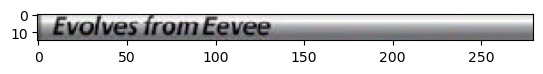

In [13]:
#Initializing dictionary for textboxes within card frame
subarrays = dict()

#taking all the coordinates and slicing a pixel subarray
for name, coords in all_boxes_P.items():
    ymin, ymax, xmin, xmax = coords
    subarrays[str(name)] = cropped_card[ymin:ymax, xmin:xmax]

    # Verify the slice isn't empty
    if subarrays[str(name)].size == 0:
        print(f"Warning: {name} resulted in an empty slice. Check coordinates!")
        continue
        
#Testing that image shows
plt.imshow(subarrays['Evolves'])